In [1]:
# Install extra libraries
# (tensorflow, numpy, pandas, matplotlib, seaborn, sklearn already hain Colab mein)
!pip install librosa soundfile tqdm

print("✅ Done!")

✅ Done!


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("✅ All libraries imported!")
print(f"   TensorFlow: {tf.__version__}")

✅ All libraries imported!
   TensorFlow: 2.20.0


In [3]:
# RAVDESS dataset download
!wget -q --show-progress \
  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip

print("✅ Download complete!")

Audio_Speech_Actors 100%[===================>] 198.81M  1.75MB/s    in 2m 48s  
✅ Download complete!


In [4]:
!unzip -q Audio_Speech_Actors_01-24.zip -d RAVDESS
print("✅ Unzip complete!")

# Verify karo
import os
actors = sorted(os.listdir('RAVDESS'))
print(f"Total Actors: {len(actors)}")
print(f"Actors: {actors}")

✅ Unzip complete!
Total Actors: 24
Actors: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [5]:
# Emotion mapping
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def get_emotion_from_filename(filename):
    parts = os.path.basename(filename).split('-')
    emotion_code = parts[2]
    return EMOTION_MAP.get(emotion_code, 'unknown')

# Total files count karo
total_files = 0
for actor in sorted(os.listdir('RAVDESS')):
    actor_path = os.path.join('RAVDESS', actor)
    if os.path.isdir(actor_path):
        files = [f for f in os.listdir(actor_path) if f.endswith('.wav')]
        total_files += len(files)

print(f"✅ Emotion function ready!")
print(f"✅ Total audio files: {total_files}")

# Test karo ek file pe
sample = "03-01-05-01-01-01-01.wav"
print(f"\n🎙️ Test: '{sample}' → {get_emotion_from_filename(sample)}")

✅ Emotion function ready!
✅ Total audio files: 1440

🎙️ Test: '03-01-05-01-01-01-01.wav' → angry


In [6]:
def extract_features(file_path, duration=3, offset=0.5):
    try:
        audio, sr = librosa.load(file_path, duration=duration, offset=offset)

        # MFCC — 40 features
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        # Chroma — 12 features
        stft = np.abs(librosa.stft(audio))
        chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Mel Spectrogram — 128 features
        mel = librosa.feature.melspectrogram(y=audio, sr=sr)
        mel_mean = np.mean(mel.T, axis=0)

        # Combine = 180 total features
        return np.hstack([mfcc_mean, chroma_mean, mel_mean])

    except Exception as e:
        print(f"⚠️ Error: {e}")
        return None

# Extract from all files
features_list = []
labels_list = []

print("⏳ Extracting features from 1440 files...")

for actor in tqdm(sorted(os.listdir('RAVDESS')), desc="Actors"):
    actor_path = os.path.join('RAVDESS', actor)
    if not os.path.isdir(actor_path):
        continue
    for audio_file in os.listdir(actor_path):
        if not audio_file.endswith('.wav'):
            continue
        file_path = os.path.join(actor_path, audio_file)
        emotion = get_emotion_from_filename(audio_file)
        features = extract_features(file_path)
        if features is not None:
            features_list.append(features)
            labels_list.append(emotion)

# DataFrame banao
df = pd.DataFrame(features_list)
df['emotion'] = labels_list

# CSV mein save karo — session crash se bachao!
df.to_csv('ravdess_features.csv', index=False)

print(f"\n✅ Feature extraction complete!")
print(f"   Total samples : {len(df)}")
print(f"   Feature count : {df.shape[1]-1}")
print(f"\n📊 Emotion Distribution:")
print(df['emotion'].value_counts())

⏳ Extracting features from 1440 files...


Actors: 100%|██████████| 24/24 [01:09<00:00,  2.91s/it]



✅ Feature extraction complete!
   Total samples : 1440
   Feature count : 180

📊 Emotion Distribution:
emotion
sad          192
fearful      192
angry        192
happy        192
calm         192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [7]:
# Features aur Labels alag karo
X = df.drop('emotion', axis=1).values
y_raw = df['emotion'].values

# Labels encode karo (text → numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
num_classes = len(le.classes_)

print(f"✅ Classes ({num_classes}): {list(le.classes_)}")

# One-hot encoding
y_onehot = to_categorical(y_encoded, num_classes=num_classes)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Normalize
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

# Reshape for LSTM/CNN
X_train_final = X_train_norm.reshape(X_train_norm.shape[0], X_train_norm.shape[1], 1)
X_test_final  = X_test_norm.reshape(X_test_norm.shape[0],  X_test_norm.shape[1],  1)

print(f"✅ Train shape: {X_train_final.shape}")
print(f"✅ Test  shape: {X_test_final.shape}")

✅ Classes (8): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
✅ Train shape: (1152, 180, 1)
✅ Test  shape: (288, 180, 1)


In [8]:
# LSTM Model
lstm_model = keras.Sequential([
    layers.LSTM(256, return_sequences=True, input_shape=(180, 1)),
    layers.Dropout(0.3),
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ LSTM Model ready!")
lstm_model.summary()

# Train karo
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n⏳ Training LSTM...")
lstm_history = lstm_model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("✅ LSTM Training complete!")

✅ LSTM Model ready!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 180, 256)       │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,088 (1.79 MB)

 Trainable params: 470,088 (1.79 MB)

 Non-trainable params: 0 (0.00 B)


⏳ Training LSTM...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2056 - loss: 2.0058 - val_accuracy: 0.2155 - val_loss: 1.9314
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2181 - loss: 1.9588 - val_accuracy: 0.1983 - val_loss: 1.9376
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2297 - loss: 1.9227 - val_accuracy: 0.1983 - val_loss: 1.8578
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2442 - loss: 1.8913 - val_accuracy: 0.2328 - val_loss: 1.9014
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2452 - loss: 1.8942 - val_accuracy: 0.2155 - val_loss: 1.9069
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2452 - loss: 1.8963 - val_accuracy: 0.2328 - val_loss: 1.8277
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2452 - loss: 1.8482 - val_accuracy: 0.2328 - val_loss: 1.8226
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2384 - loss: 1.8744 - val_

In [9]:
# CNN Model
cnn_model = keras.Sequential([
    layers.Conv1D(64, kernel_size=5, activation='relu',
                  padding='same', input_shape=(180, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),

    layers.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),

    layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ CNN Model ready!")

# Train karo
print("\n⏳ Training CNN...")
cnn_history = cnn_model.fit(
    X_train_final, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )],
    verbose=1
)
print("✅ CNN Training complete!")

✅ CNN Model ready!

⏳ Training CNN...
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - accuracy: 0.2857 - loss: 1.8706 - val_accuracy: 0.1207 - val_loss: 2.0489
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3263 - loss: 1.7414 - val_accuracy: 0.1207 - val_loss: 2.0880
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3456 - loss: 1.7354 - val_accuracy: 0.1466 - val_loss: 2.1497
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3465 - loss: 1.7045 - val_accuracy: 0.1379 - val_loss: 2.1719
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3523 - loss: 1.6828 - val_accuracy: 0.1034 - val_loss: 2.3280
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3649 - loss: 1.6426 - val_accuracy: 0.0862 - val_loss: 2.4591
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3678 - loss: 1.6373 - val_accuracy: 0.0948 - val_loss: 2.6515
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3842 

✅ CNN Test Accuracy: 57.29%


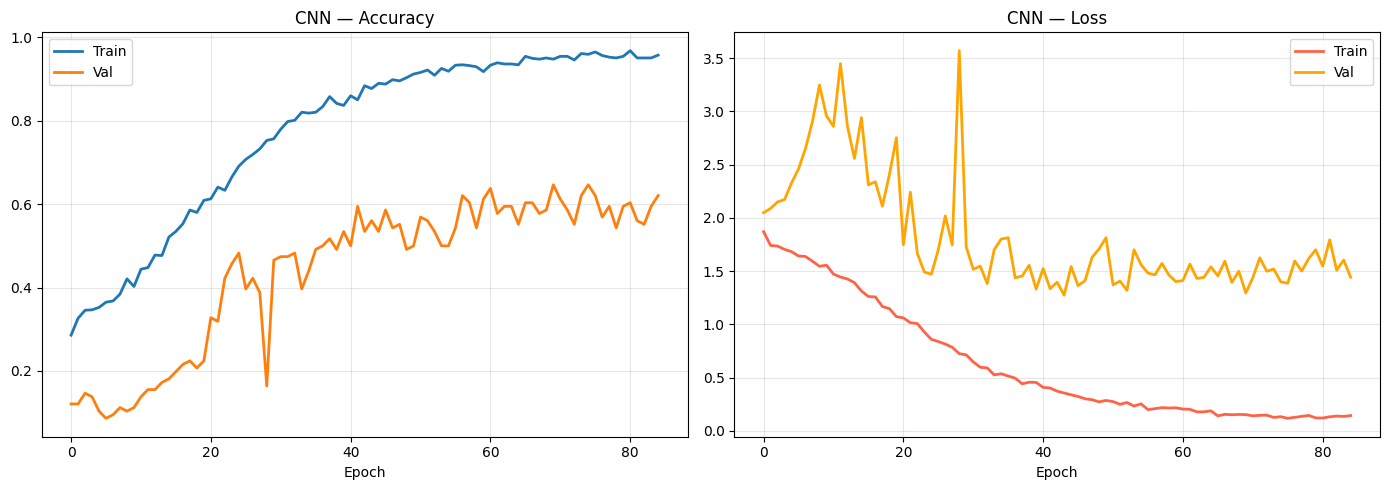

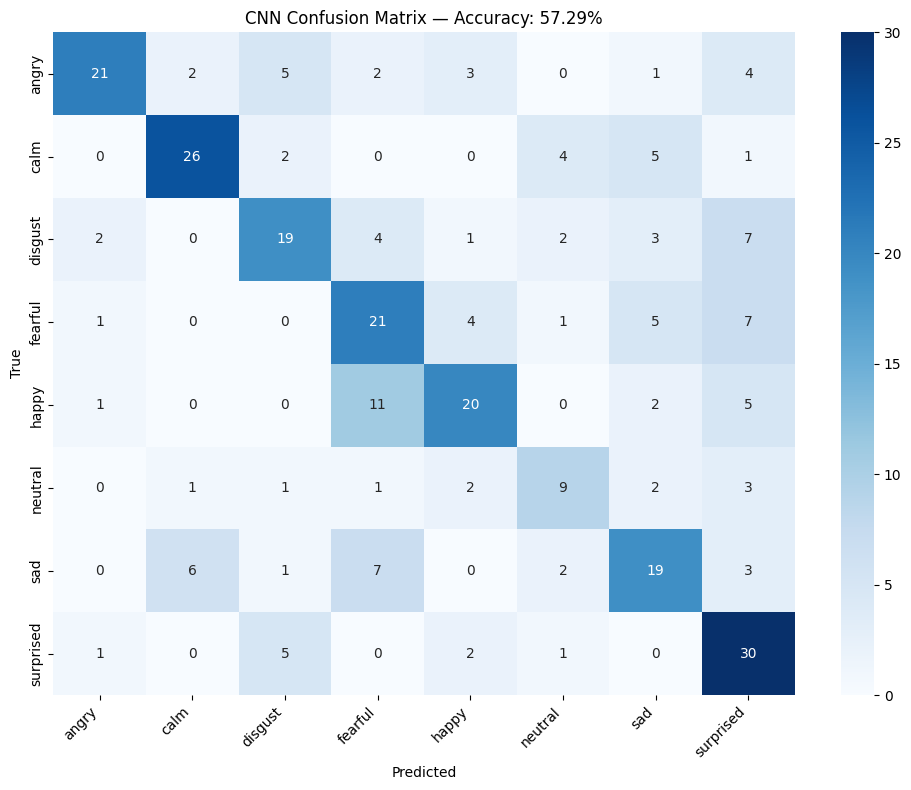


📊 Per-Emotion Results:
              precision    recall  f1-score   support

       angry       0.81      0.55      0.66        38
        calm       0.74      0.68      0.71        38
     disgust       0.58      0.50      0.54        38
     fearful       0.46      0.54      0.49        39
       happy       0.62      0.51      0.56        39
     neutral       0.47      0.47      0.47        19
         sad       0.51      0.50      0.51        38
   surprised       0.50      0.77      0.61        39

    accuracy                           0.57       288
   macro avg       0.59      0.57      0.57       288
weighted avg       0.59      0.57      0.57       288



In [10]:
# Test Accuracy
loss, accuracy = cnn_model.evaluate(X_test_final, y_test, verbose=0)
print(f"✅ CNN Test Accuracy: {accuracy*100:.2f}%")

# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title('CNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['loss'],     label='Train', color='tomato', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Val',   color='orange', linewidth=2)
axes[1].set_title('CNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred = np.argmax(cnn_model.predict(X_test_final, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title(f'CNN Confusion Matrix — Accuracy: {accuracy*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📊 Per-Emotion Results:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

In [11]:
import pickle

# Model save
cnn_model.save('emotion_recognition_model.h5')

# Label encoder save
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Normalization stats save
np.save('X_mean.npy', X_mean)
np.save('X_std.npy',  X_std)

print("✅ Model saved: emotion_recognition_model.h5")
print("✅ Label encoder saved: label_encoder.pkl")
print("✅ Normalization stats saved!")

# Google Drive mein bhi save karo
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('emotion_recognition_model.h5',
            '/content/drive/MyDrive/emotion_recognition_model.h5')
shutil.copy('label_encoder.pkl',
            '/content/drive/MyDrive/label_encoder.pkl')
print("✅ Files Drive mein bhi save ho gayi!")

✅ Model saved: emotion_recognition_model.h5
✅ Label encoder saved: label_encoder.pkl
✅ Normalization stats saved!
Mounted at /content/drive
✅ Files Drive mein bhi save ho gayi!


In [14]:
from google.colab import files
import librosa
import numpy as np
import pickle

# File upload karo
print("⬆️ Apni audio file upload karo...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ File uploaded: {filename}")

# Convert karo agar .m4a hai tu
if filename.endswith('.m4a') or filename.endswith('.mp3'):
    !ffmpeg -i "{filename}" -ar 22050 converted_audio.wav -y -q:a 0
    filename = 'converted_audio.wav'
    print("✅ Converted to wav!")

# Features extract karo
audio, sr = librosa.load(filename, duration=3, offset=0.0)

mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
stft   = np.abs(librosa.stft(audio))
chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
mel    = librosa.feature.melspectrogram(y=audio, sr=sr)

features = np.hstack([
    np.mean(mfcc.T,   axis=0),
    np.mean(chroma.T, axis=0),
    np.mean(mel.T,    axis=0)
])

# Normalize
features_norm  = (features - X_mean) / X_std
features_input = features_norm.reshape(1, 180, 1)

# Predict
prediction   = cnn_model.predict(features_input, verbose=0)
emotion_idx  = np.argmax(prediction)
confidence   = prediction[0][emotion_idx] * 100
emotion_name = le.classes_[emotion_idx]

# Result
print("\n" + "="*40)
print("🎭 EMOTION PREDICTION")
print("="*40)
print(f"🏆 Detected : {emotion_name.upper()}")
print(f"📊 Confidence: {confidence:.2f}%")
print("\n📈 All Emotions:")
for emo, prob in zip(le.classes_, prediction[0]):
    bar = "█" * int(prob * 25)
    print(f"   {emo:<12} {bar} {prob*100:.1f}%")

⬆️ Apni audio file upload karo...


KeyboardInterrupt: 